# Diffusion: directly fit G, preserve D=GGᵀ
The five-PC teacher has general noise and one Brownian driver. The symbolic field is a (batch,5,1) factor, not a scalar magnitude or a diagonal noise model. Fit is performed only after the drift validation gate succeeds.

In [1]:
from pathlib import Path
import os,sys,json
ROOT=Path.cwd()
if ROOT.name=='notebooks':ROOT=ROOT.parent
os.chdir(ROOT);sys.path.insert(0,str(ROOT))
import pandas as pd,numpy as np
from IPython.display import display,Image,Markdown


,degree,alpha,threshold,library_size,active_terms,train_mse,validation_mse,train_nrmse,validation_nrmse
0,1,1.0,0.01,6,30,0.003295,0.003295,0.484456,0.521546
1,1,1.0,0.05,6,29,0.003296,0.003296,0.484492,0.521651
2,1,1.0,0.10,6,27,0.003307,0.003297,0.485303,0.521694
3,1,10.0,0.01,6,30,0.003295,0.003293,0.484470,0.521395
4,1,10.0,0.05,6,29,0.003296,0.003294,0.484506,0.521500
5,1,10.0,0.10,6,27,0.003307,0.003295,0.485317,0.521545
6,1,100.0,0.01,6,30,0.003307,0.003286,0.485357,0.520855
7,1,100.0,0.05,6,29,0.003308,0.003287,0.485391,0.520948
8,1,100.0,0.10,6,27,0.003319,0.003289,0.486229,0.521051
9,2,1.0,0.01,21,103,0.001051,0.001172,0.273619,0.311110


,partition,mse,nrmse,cosine_mean,error_norm_q95,error_norm_max
0,train,0.001148,0.285924,0.840091,0.133396,0.436643
1,validation,0.001310,0.328905,0.809436,0.132912,0.722254
2,test,0.001483,0.358287,0.840796,0.163166,0.502806
3,test_in_domain,0.001467,0.357434,0.840684,0.162679,0.451295


{'degree': 2, 'alpha': 100.0, 'threshold': 0.1, 'library_size': 21, 'active_terms': 61, 'train_mse': 0.0011477809660304344, 'validation_mse': 0.0013103352858064902, 'train_nrmse': 0.28592417073738274, 'validation_nrmse': 0.32890524379371694}
[{'threshold': 0.09000000000000001, 'active_terms': 62, 'support_jaccard': 0.9838709677419355, 'validation_nrmse': 0.3274610210090806}, {'threshold': 0.11000000000000001, 'active_terms': 57, 'support_jaccard': 0.9032258064516129, 'validation_nrmse': 0.33400076783298843}]


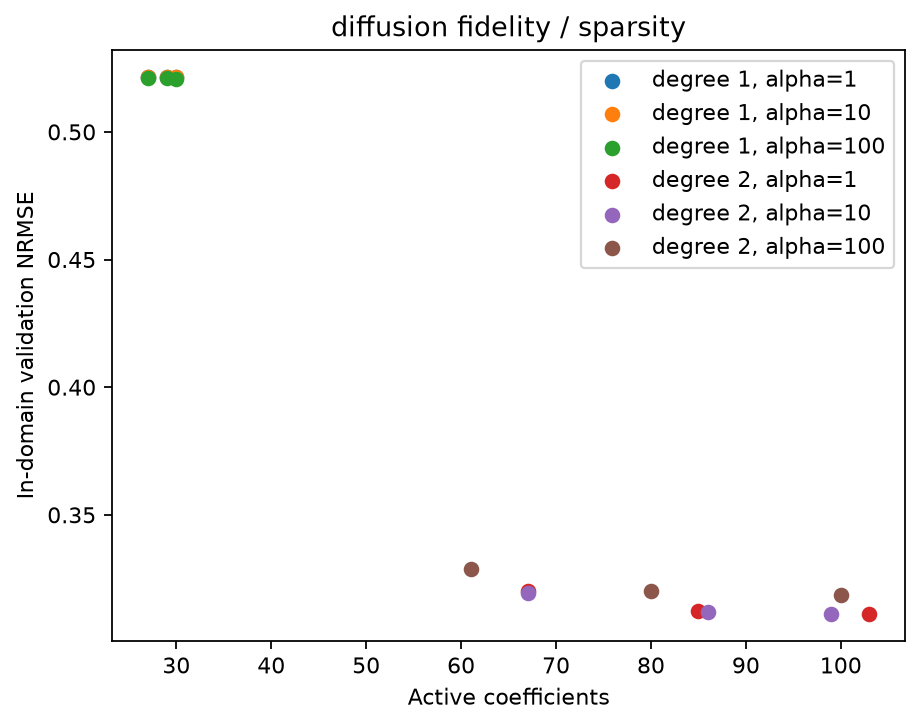

In [2]:
drift_result=json.loads(Path('outputs/sindy_pc5/drift/results.json').read_text())
assert drift_result['function_success'], 'Drift gate failed; diffusion is intentionally deferred'
root=Path('outputs/sindy_pc5/diffusion')
result=json.loads((root/'results.json').read_text())
display(pd.read_csv(root/'sweep.csv'))
display(pd.DataFrame([{ 'partition':name, **result[name]} for name in ('train','validation','test','test_in_domain')]))
print(result['selected']);print(result['threshold_jitter'])
display(Image(filename='outputs/figures/pc5_diffusion_sparsity.png'))

In [3]:
from src.distill import PolynomialField,SymbolicSDE
import torch
f=PolynomialField.load(Path('outputs/sindy_pc5/drift/model.npz'))
g=PolynomialField.load(root/'model.npz')
model=SymbolicSDE(f,g)
x=torch.zeros((4,5),dtype=torch.float32)
G=model.g(torch.tensor(2.),x)
D=G@G.transpose(-1,-2)
print('G',tuple(G.shape),'D',tuple(D.shape),'minimum eigenvalue',float(torch.linalg.eigvalsh(D).min()))
display(Markdown((root/'equations.md').read_text()))

G (4, 5, 1) D (4, 5, 5) minimum eigenvalue -2.7257309742623193e-09


# Polynomial field equations

Output units: PC coordinate / sqrt(day)
Only powers and their monomial interactions are used. Coordinate definitions:

z1 = (PC1 - (3.27761887)) / (7.28231268)
z2 = (PC2 - (-2.70247384)) / (3.33683085)
z3 = (PC3 - (0.536390761)) / (5.89675952)
z4 = (PC4 - (-1.36712844)) / (1.96920731)
z5 = (PC5 - (1.27192052)) / (1.72974099)

field_1 = (0.0164339479)*1 + (0.0234427411)*z2 + (0.0233773235)*z3 + (0.0270959299)*z4 + (-0.0172764739)*z5 + (0.027156999)*z1^2 + (-0.0226834163)*z1*z2 + (0.0246218836)*z1*z5 + (0.00507191831)*z2^2 + (0.00914236788)*z2*z4 + (-0.0273085009)*z3^2 + (0.0184506191)*z3*z4 + (-0.00654099086)*z3*z5 + (0.00574742478)*z4^2 + (-0.00929099453)*z4*z5

field_2 = (-0.083360788)*1 + (-0.0583545659)*z1 + (0.0655252311)*z2 + (0.0674650399)*z3 + (0.0224530816)*z1^2 + (-0.0136916854)*z1*z2 + (-0.0147292957)*z2*z3 + (-0.00777553154)*z3^2 + (0.0216301398)*z3*z5 + (0.0145633965)*z4^2

field_3 = (0.0435696345)*1 + (-0.027815216)*z1 + (0.0879646862)*z3 + (0.0469970427)*z4 + (-0.0181562881)*z5 + (0.0727789879)*z1^2 + (-0.0433867721)*z1*z2 + (-0.0477125579)*z1*z4 + (0.0244014216)*z1*z5 + (-0.0230975443)*z2*z3 + (-0.0113428586)*z3^2 + (-0.0194813816)*z3*z4 + (-0.0119659701)*z4*z5

field_4 = (-0.0485384797)*1 + (-0.0893876039)*z1 + (0.0485247504)*z2 + (0.0625985126)*z3 + (-0.0305686665)*z1^2 + (0.0248987285)*z1*z2 + (-0.00959563972)*z2^2 + (0.0303013427)*z2*z3 + (-0.00797432854)*z4*z5

field_5 = (-0.0487728403)*1 + (-0.0308702324)*z1 + (-0.0292545937)*z2 + (0.067070594)*z3 + (0.0222511243)*z5 + (-0.010362517)*z1^2 + (-0.011444712)*z1*z2 + (-0.0166913771)*z1*z3 + (0.0119016466)*z1*z4 + (-0.0152660865)*z1*z5 + (-0.0121555951)*z2*z3 + (-0.00589922649)*z2*z5 + (0.00777342926)*z3^2 + (0.00836099539)*z3*z5

Each G component uses polynomial powers/interactions only. Forming D multiplies these fitted functions and can increase polynomial degree; this is covariance construction, not a new candidate library. PSD is structural, but it does not establish intrinsic biological noise or uniquely identified diffusion. Equality to a teacher factor is stronger than the identifiable covariance alone; another Brownian-factor gauge can represent the same law.

実際の選択済みモデルを1,169個の観測状態で監査する。NumPy と積分用 Torch の二次交差項評価が一致することを確認する。D の微小な負の固有値は浮動小数点丸めの範囲であり、因子構造 GGᵀ は PSD を保つ。

In [4]:
states=np.load('outputs/distillation_pc5/observed_states.npy')[::8]
audit={}
for dtype in (torch.float32,torch.float64):
    sde=SymbolicSDE(f,g,dtype=dtype)
    xt=torch.tensor(states,dtype=dtype)
    for name,field,value in [('f',f,sde.f(torch.tensor(2.),xt)),('G',g,sde.g(torch.tensor(2.),xt).squeeze(-1))]:
        expected=field.predict(states);actual=value.detach().numpy()
        np.testing.assert_allclose(actual,expected,rtol=2e-4,atol=2e-5 if dtype==torch.float32 else 1e-10)
        audit[f'{dtype}_{name}_max_abs_error']=float(abs(actual-expected).max())
    GG=sde.g(torch.tensor(2.),xt)
    audit[f'{dtype}_D_min_eigenvalue']=float(torch.linalg.eigvalsh(GG@GG.transpose(-1,-2)).min())
audit.update(n_states=len(states),passed=True,interpretation='Actual selected quadratic interaction models agree across NumPy/Torch; PSD within floating-point tolerance.')
Path('outputs/logs/pc5_symbolic_evaluator_audit.json').write_text(json.dumps(audit,indent=2))
audit

{'torch.float32_f_max_abs_error': 2.255959320240919e-06,
 'torch.float32_G_max_abs_error': 8.24461977577684e-08,
 'torch.float32_D_min_eigenvalue': -3.502533729715651e-08,
 'torch.float64_f_max_abs_error': 3.552713678800501e-15,
 'torch.float64_G_max_abs_error': 3.3306690738754696e-16,
 'torch.float64_D_min_eigenvalue': -1.9534791178999954e-16,
 'n_states': 1169,
 'passed': True,
 'interpretation': 'Actual selected quadratic interaction models agree across NumPy/Torch; PSD within floating-point tolerance.'}